**Разработка DL-модели, способной оценить калорийность блюда.**  

**Цель:**  
Получить DL-модель, способную оценить калорийность блюда.  
**Целевая метрика:**  
Модель будет считаться готовой к интеграции в продукт при точности оценки MAE < 50 (MAE — Mean Absolute Error) на тестовой выборке.   
**Датасет:**  
Датасет содержит фотографии блюд, описание ингредиентов, а также общую массу порции и калорийность:  
- data/ingredients.csv  
    - id — ID ингредиента.  
    - ingr — название ингредиента.  
- data/dish.csv  
    - dish_id — ID блюда.  
    - total_calories — общее число калорий. Это целевая переменная.  
    - total_mass — масса блюда.  
    - ingredients — список всех ID ингредиентов в формате ingr_0000000122;ingr_0000000026;.., где ненулевая часть соответствует ID ингредиента из data/ingredients.csv.  
    - split — метка, указывающая, куда отнести блюдо: train/test. Эта метка поможет разделить датасет при тренировке.  
    - data/images — датасет с фотографиями блюд, каждая директория соответствует dish_id из data/dish.csv и содержит rgb.png фото блюда.  

**Этап 0. Загрузка библиотек**

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import shutil
from torchvision.datasets import ImageFolder
from matplotlib import pyplot as plt
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from PIL import Image
import scripts.utils as sc_ut
from scripts.config import get_config

/home/ubuntu/proj/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
pip install seaborn

In [4]:
#Инициализируем конфиг
cfg = get_config()

**Этап 1. Исследовательский анализ (EDA)**

Загрузим датасет и визуализируем часть данных. Изучим то, с чем предстоит работать.

In [5]:
#Загрузим датасеты
ingredients = pd.read_csv(cfg.DF_PRODUCT_PATH)
dish = pd.read_csv(cfg.DF_GENERAL_PATH)
dataset = ImageFolder(cfg.IMAGE_PATH)

In [6]:
#Посмотрим на датасет ingredients.csv:
print('Размер ingredients.csv: ', ingredients.shape)
ingredients.head()

Размер ingredients.csv:  (555, 2)


,id,ingr
0,1,cottage cheese
1,2,strawberries
2,3,garden salad
3,4,bacon
4,5,potatoes


In [7]:
ingredients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      555 non-null    int64 
 1   ingr    555 non-null    object
dtypes: int64(1), object(1)
memory usage: 8.8+ KB


In [8]:
#Посмотрим на датасет dish.csv:
print('Размер dish.csv: ', dish.shape)
dish.head()

Размер dish.csv:  (3262, 5)


,dish_id,total_calories,total_mass,ingredients,split
0,dish_1561662216,300.794281,193.0,ingr_0000000508;ingr_0000000122;ingr_000000002...,test
1,dish_1561662054,419.438782,292.0,ingr_0000000312;ingr_0000000026;ingr_000000002...,train
2,dish_1562008979,382.936646,290.0,ingr_0000000448;ingr_0000000520;ingr_000000046...,test
3,dish_1560455030,20.590000,103.0,ingr_0000000471;ingr_0000000031;ingr_0000000347,train
4,dish_1558372433,74.360001,143.0,ingr_0000000453,train


In [9]:
dish.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3262 entries, 0 to 3261
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dish_id         3262 non-null   object 
 1   total_calories  3262 non-null   float64
 2   total_mass      3262 non-null   float64
 3   ingredients     3262 non-null   object 
 4   split           3262 non-null   object 
dtypes: float64(2), object(3)
memory usage: 127.5+ KB


In [10]:
dish.describe()

,total_calories,total_mass
count,3262.000000,3262.000000
mean,255.012738,214.980074
std,219.637570,161.497428
min,0.000000,1.000000
25%,80.114996,92.000000
50%,209.110062,177.000000
75%,375.122963,305.000000
max,3943.325195,3051.000000


total_calories: MAX до 3944 ккал.  
total_mass: MAX до 3051 г.  
Также видна нулевая калорийность и масса блюда в 1 грамм, но это возможно, удалять не будем.

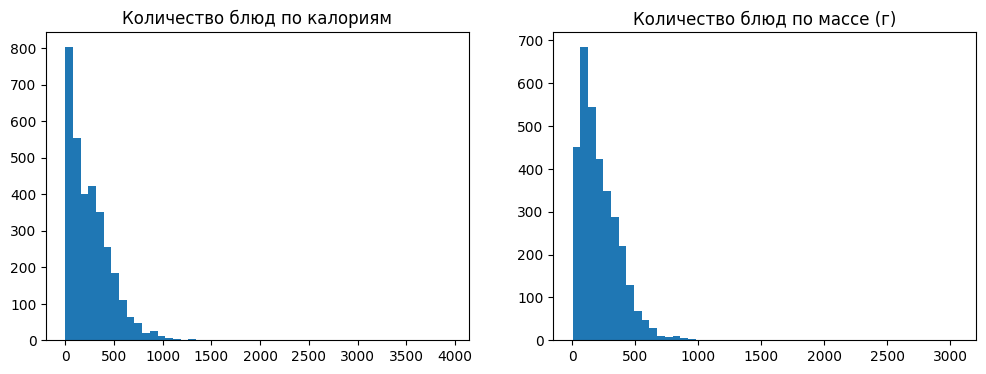

In [11]:
#Визуализируем распределения
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].hist(dish["total_calories"], bins=50)
axs[0].set_title("Количество блюд по калориям")
axs[1].hist(dish["total_mass"], bins=50)
axs[1].set_title("Количество блюд по массе (г)")
plt.show()

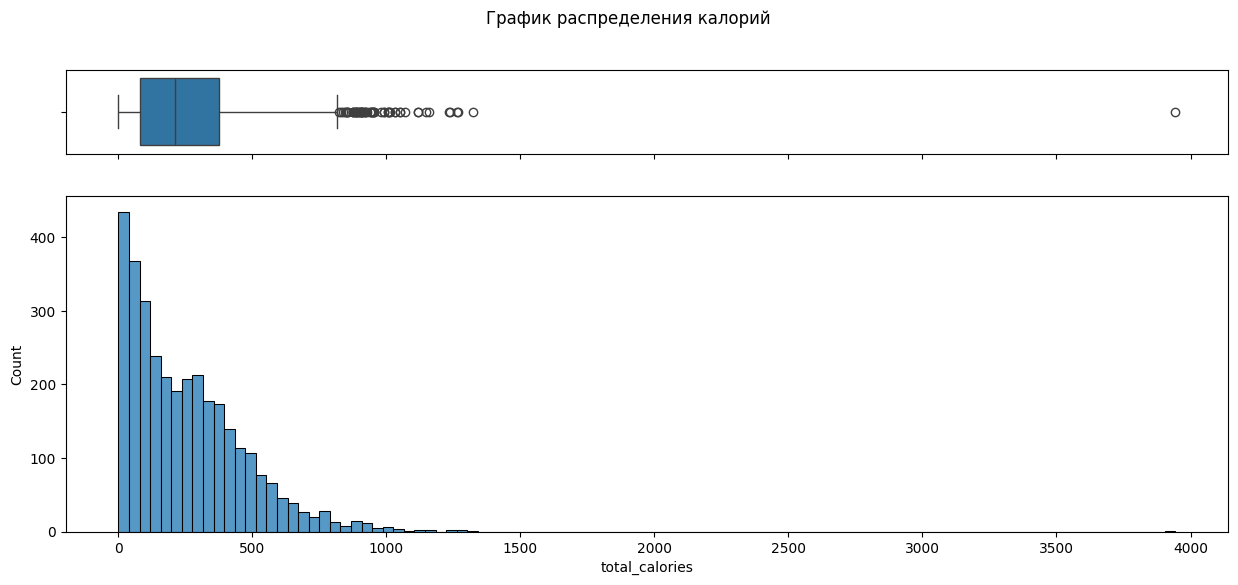

In [12]:
#Посмотрим на "выбросы" по калориям
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(15, 6), sharex=True, height_ratios=(0.20, 0.80))
sns.boxplot(data=dish, x='total_calories', ax=ax_box)
sns.histplot(data=dish, x='total_calories', ax=ax_hist)
fig.suptitle('График распределения калорий')
plt.show()

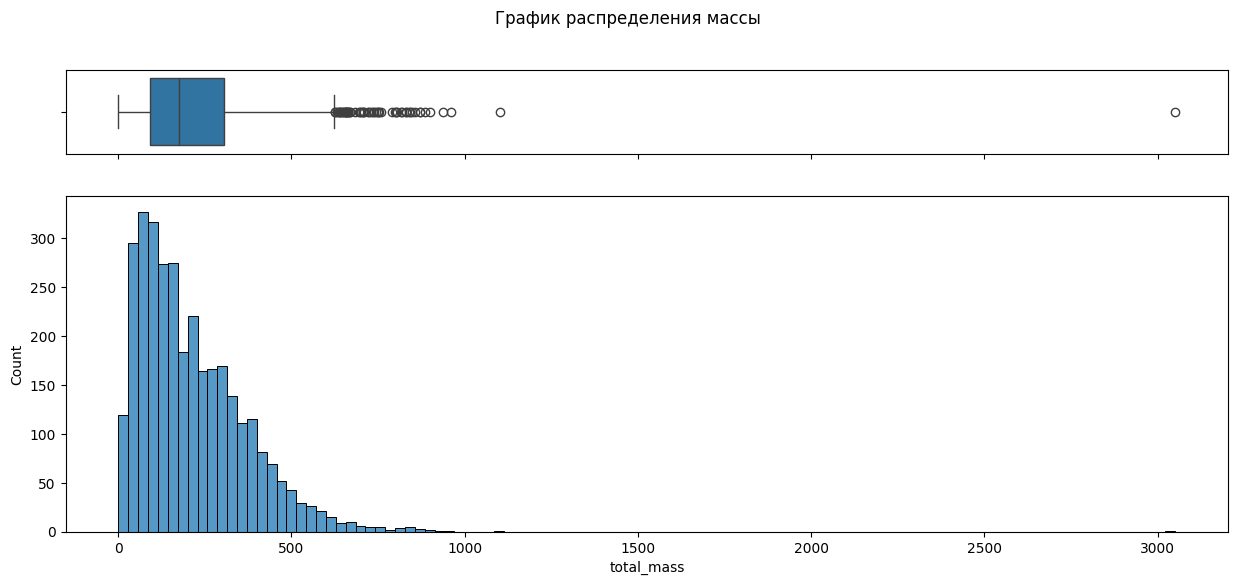

In [13]:
#Посмотрим на "выбросы" по массе (г)
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(15, 6), sharex=True, height_ratios=(0.20, 0.80))
sns.boxplot(data=dish, x='total_mass', ax=ax_box)
sns.histplot(data=dish, x='total_mass', ax=ax_hist)
fig.suptitle('График распределения массы')
plt.show()

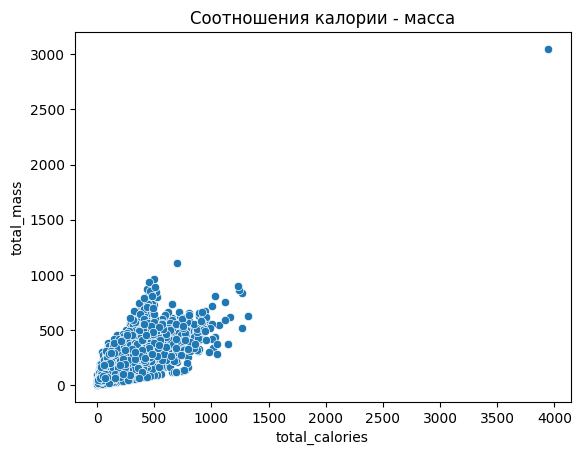

In [14]:
#Визуализируем соотношение количество калорий-масса
sns.scatterplot(x=dish['total_calories'], y=dish['total_mass'])
plt.title('Соотношения калории - масса')
plt.show()

Видно, что самое тяжелое блюдо имеет самую большую калорийность, судя по графику нельзя сказать, что это какая-то ошибка, однако из общего датасета оно выделяется как "выброс".


Блюдо с максимальным количеством калорий:
ID: dish_1560974769
Калории: 3943.325195
Масса: 3051.0 г
Ингредиенты:
  - spinach (raw)
  - tortilla chips
  - corn
  - cheese
  - white rice
  - cherry tomatoes
  - lime
  - tomatoes
  - chili
  - garlic
  - salt
  - sour cream
  - onions
  - black beans


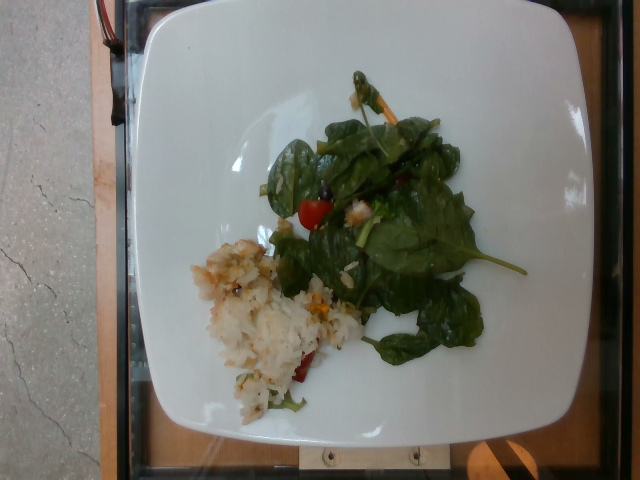

In [15]:
#Отобразим блюдо с самой высокой колорийностью.
#Блюдо с максимальным количеством калорий
max_calorie_dish = dish.loc[dish['total_calories'].idxmax()]
#ID самого калорийного блюда
max_calorie_dish_id = max_calorie_dish['dish_id']
#Общее количество калорий этого блюда
max_calorie_dish_total_calories = max_calorie_dish['total_calories']
#Общую масса блюда в граммах
max_calorie_dish_total_mass = max_calorie_dish['total_mass']
#ID ингредиентов 
ingredients_list = max_calorie_dish['ingredients'].split(';')
#Получаем названия ингредиентов
ingredients_map = dict(zip(ingredients['id'], ingredients['ingr']))
text_list = []
for row in ingredients_list:
    ingr_ids = []
    for part in row.split(';'):
        part = part.strip()
        if part.startswith('ingr_'):
            num_str = part[5:]
            if num_str.isdigit():
                ingr_ids.append(int(num_str))
    ingr_names = [ingredients_map.get(i, "unknown") for i in ingr_ids]
    text = " ".join(ingr_names)
    text_list.append(text)

#Вывод информации
print(f"\nБлюдо с максимальным количеством калорий:")
print(f"ID: {max_calorie_dish_id}")
print(f"Калории: {max_calorie_dish_total_calories}")
print(f"Масса: {max_calorie_dish_total_mass} г")
print("Ингредиенты:")
for name in text_list:
    print(f"  - {name}")

#Путь к изображению
image_path = f'data/images/{max_calorie_dish_id}/rgb.png'
if os.path.exists(image_path):
    img = Image.open(image_path)
    display(img)
else:
    print(f"Фото не найдено: {image_path}")

Судя по перечню ингридиентов и фото - все совпадает, однако их количество явно не тянет на 3051 г. Я подозреваю, что количество как и калории были завышены в 10 раз. Информация и фото не соответствуют, поэтому удалим данный выброс.

In [16]:
#Инициализируем список всех папок с изображениями
missing_images = []
# Проверим, существует ли папка и файл rgb.png
for dish_id in dish['dish_id']:
    folder_path = os.path.join(cfg.IMAGE_PATH, str(dish_id))
    img_path = os.path.join(folder_path, "rgb.png")
    if not os.path.exists(img_path):
        missing_images.append(dish_id)

print(f"Блюд без фото: {len(missing_images)}")
if missing_images:
    print("Примеры:", missing_images[:5])

Блюд без фото: 0


In [17]:
# Удаляем выбросы
extra_calories = 2000
dish_cleaned = dish[dish['total_calories'] < extra_calories]
print(f"Блюд после удаления выброса: {len(dish_cleaned)}")
print(f"Удалено: {len(dish) - len(dish_cleaned)} блюд")

Блюд после удаления выброса: 3261
Удалено: 1 блюд


In [18]:
# Получаем ID блюда, которые удаляем
removed_id = set(dish[dish['total_calories'] > extra_calories]['dish_id'])
print(f"Удаляем фото для {len(removed_id)} блюда.")
# Удаляем папки
deleted_count = 0

for dish_id in removed_id:
    folder_path = os.path.join(cfg.IMAGE_PATH, str(dish_id))
    if os.path.exists(folder_path):
        shutil.rmtree(folder_path)
        deleted_count += 1

print(f"Удалено папок с фото: {deleted_count}")

Удаляем фото для 1 блюда.
Удалено папок с фото: 1


In [19]:
#Примем очищенный датасет за основу дальнейшего исследования
dish = dish_cleaned

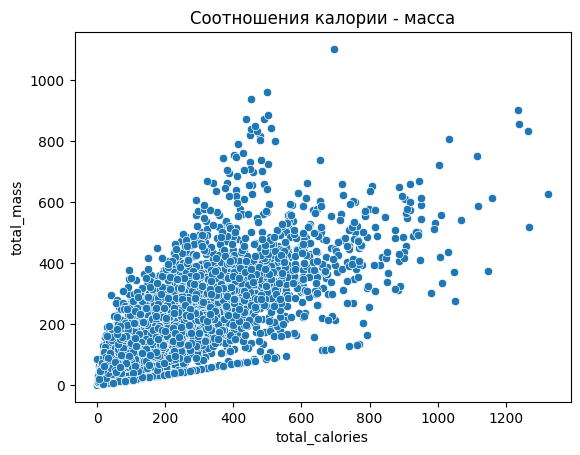

In [20]:
#Проверим визуализацию соотношения количества калорий-масса
sns.scatterplot(x=dish['total_calories'], y=dish['total_mass'])
plt.title('Соотношения калории - масса')
plt.show()

In [21]:
#Проверим на уникальность ингридиентов для обучающего набора блюд и тестовых
unique_train = []
unique_test = []

for e in dish.loc[dish.split =='train','ingredients']:
    unique_train.extend(e.split(';'))
unique_train = set(unique_train)
print('Уникальные ингредиенты в трейне:', len(unique_train))

for e in dish.loc[dish.split =='test','ingredients']:
    unique_test.extend(e.split(';'))
unique_test = set(unique_train)
print('Уникальные ингредиенты в тесте:', len(unique_test))

print('Разница между ингредиентами отсутствует:', len(unique_train.difference(unique_test)))

Уникальные ингредиенты в трейне: 198
Уникальные ингредиенты в тесте: 198
Разница между ингредиентами отсутствует: 0


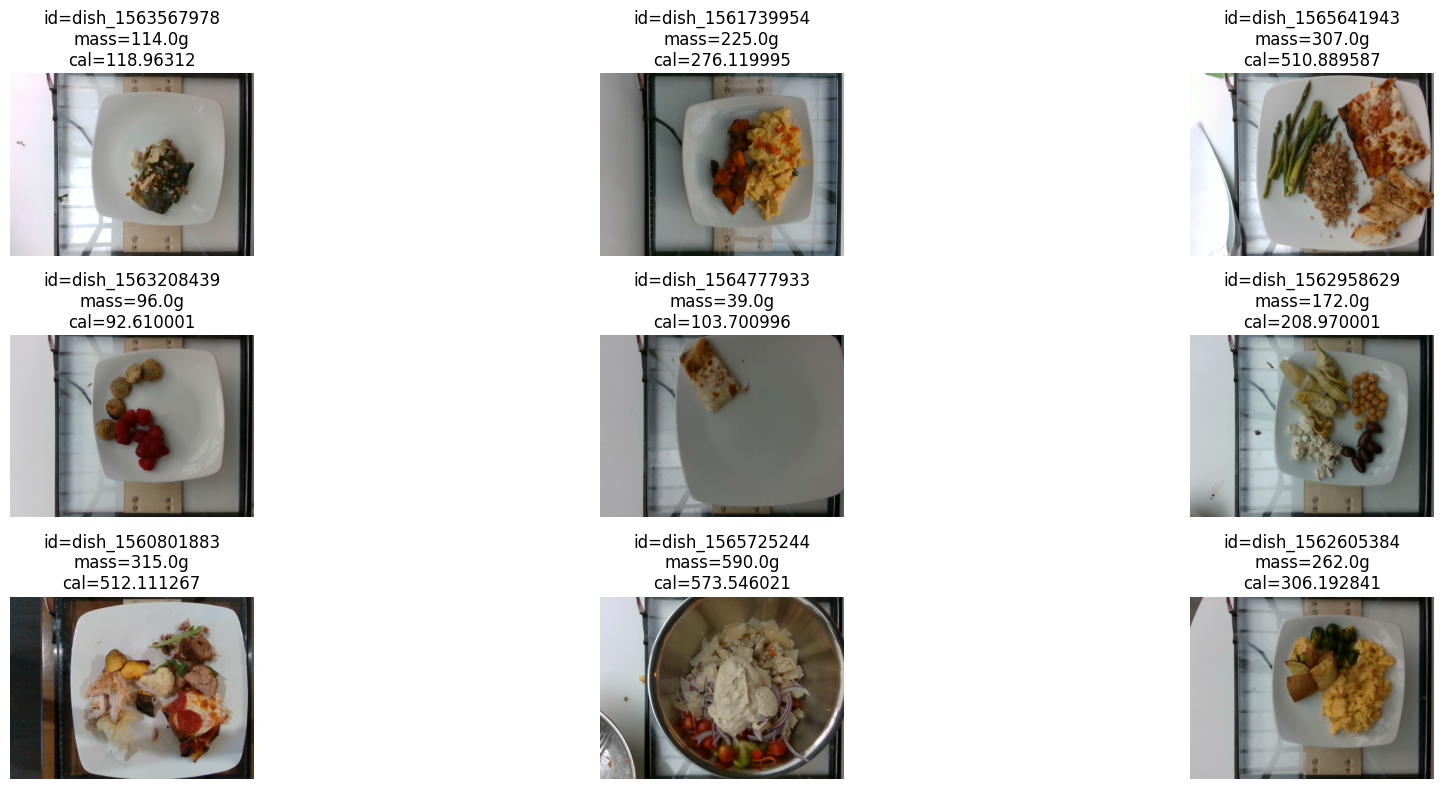

In [22]:
#Визуализация 9 примеров

sample_df = dish.sample(9, random_state=cfg.SEED)

fig, axs = plt.subplots(3, 3, figsize=(20, 8))
axs = axs.flatten()

for ax, (_, row) in zip(axs, sample_df.iterrows()):
    dish_id = row["dish_id"]
    folder_path = os.path.join(cfg.IMAGE_PATH, str(dish_id))
    img_path = os.path.join(folder_path, "rgb.png")
    
    if os.path.exists(folder_path):
        img = Image.open(img_path)
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(
            f"id={dish_id}\n"
            f"mass={row['total_mass']}g\n"
            f"cal={row['total_calories']}"
        )
    else:
        ax.text(0.5, 0.5, f"id={dish_id}\nNO IMAGE", ha="center", va="center")
        ax.axis("off")

plt.tight_layout()
plt.show()

In [23]:
print('Фотографии в наличии по всем блюдам имеются: ', dish.shape[0]==dish[dish.dish_id.isin(dataset.classes)].shape[0])

Фотографии в наличии по всем блюдам имеются:  True


**Результаты по выполнению Этапа 1:**    

Изначальный датасет содержал 3262 блюда, каждое из которых имело фотографию, список ингредиентов, массу порции и целевую переменную — общую калорийность.
Пропусков в данных нет, структура таблиц соответствует описанию датасета.
Все блюда в датасете имеют изображения, поэтому основная модель может опираться на визуальную информацию без необходимости обработки отсутствующих изображений.
Распределение калорийности и массы порции имело выбросы (очень калорийные и тяжёлые блюда).
От выброса по массе и калорийности мы избавились, осталось 3261 блюдо.
Визуальный осмотр изображений показывает однородный формат.
На основании проведённого анализа целесообразно использовать мультимодальный подход, объединяющий: визуальные признаки изображения, эмбеддинги ингредиентов и числовую характеристику массы блюда.

Видение:  
- Как я буду решать задачу:  
Буду использовать мультимодальную сеть, в том числе примеры из обучающих уроков. Добавлю total_mass, как дополнительный признак для финального блока. Регрессионный слой начну с простого полносвязанного слоя, но можно будет использовать и промежуточный слой с целью постепенного понижения размерности.  
- Какие подходы к обогащению/аугментации данных приму:  
Буду использовать случайное вырезание квадрата, вращение изображения, аффинное преобразование и изменение цвета - стандартный набор из того, что было на курсе.
Дропаут не буду делать, так как некоторые продукты могут пропасть из изображения.  
- На какие метрики буду ориентироваться при обучении: основная - MAE, дополнительно - MSE.

**Этап 2. Пайплайн обучения**

Задача:  
Используя .py-файлы для сохранения кода, реализуйте:  
Загрузчики данных и датасеты.  
Опциональный код предобработки/аугментации данных.  
Код обучения и валидации для импортирования в виде одной функции (train).  
Конфиг-файл для запуска модели и сохранения результатов обучения.  
Код для получения воспроизводимых результатов (seed) с выводом метрик.  
Рекомендуемая структура: первый файл для работы с данными назовите dataset.py, второй — по запуску обучения — utils.py.  

Планируемый результат:  
Python-файл или файлы с воспроизводимым кодом обучения.  
Все результаты должны воспроизводиться путём вызова train с передачей конфигурационного файла.  

Реализация:  
- Конфигурационный файл эксперимента (scripts/config.py).  
В данном файле реализуется конфигурация эксперимента, содержащая все параметры, необходимые для воспроизводимого обучения модели: пути к данным, гиперпараметры, настройки модели и обучения.  
- Файл загрузки и подготовка данных (scripts/dataset.py).  
В данном файле реализован класс датасета и вспомогательные функции для загрузки и подготовки данных к обучению модели.  
Основные компоненты реализации:  
    - Класс MultimodalDataset загружает изображение блюда, преобразует список ингредиентов в последовательность индексов, возвращает массу порции и целевую переменную;   
    - Функция get_transforms применяет аугментации, использование различных трансформаций изображений для обучающей и валидационной выборок;  
    - Функция collate_fn объединяет объекты в батчи с паддингом последовательностей ингредиентов и формированием масок.  
Такая структура датасета обеспечивает корректную работу с мультимодальными данными и позволяет гибко управлять процессом обучения модели.
- Файл обучения и валидации (scripts/utils.py).  
В данном разделе реализуются функции обучения и валидации модели, а также вспомогательные компоненты для обеспечения воспроизводимости экспериментов.

Реализация включает:
- фиксацию генераторов случайных чисел для воспроизводимости;
- функции одного шага обучения и валидации;
- расчёт метрики MAE и MSE;
- основной цикл обучения с сохранением лучшей модели по валидационной метрике.
Все этапы обучения вынесены в отдельный файл utils.py, что позволяет запускать процесс обучения из ноутбука одной функцией.

**Этап 3. Обучение модели**

In [24]:
sc_ut.train(cfg, cfg.DEVICE)

Разморожен слой: encoder.layer.11.attention.self.query.weight
Разморожен слой: encoder.layer.11.attention.self.query.bias
Разморожен слой: encoder.layer.11.attention.self.key.weight
Разморожен слой: encoder.layer.11.attention.self.key.bias
Разморожен слой: encoder.layer.11.attention.self.value.weight
Разморожен слой: encoder.layer.11.attention.self.value.bias
Разморожен слой: encoder.layer.11.attention.output.dense.weight
Разморожен слой: encoder.layer.11.attention.output.dense.bias
Разморожен слой: encoder.layer.11.attention.output.LayerNorm.weight
Разморожен слой: encoder.layer.11.attention.output.LayerNorm.bias
Разморожен слой: encoder.layer.11.intermediate.dense.weight
Разморожен слой: encoder.layer.11.intermediate.dense.bias
Разморожен слой: encoder.layer.11.output.dense.weight
Разморожен слой: encoder.layer.11.output.dense.bias
Разморожен слой: encoder.layer.11.output.LayerNorm.weight
Разморожен слой: encoder.layer.11.output.LayerNorm.bias
Разморожен слой: pooler.dense.weight
Раз

Результат выполнения Этапа 3:  
- Обучение модели прровели на предоставленной ВМ с использованием кода с Этапа 2.  
- Запуск обучения проводите в файле "notebook.ipynb" (Jupyter Notebook) с логированием результатов в stdout-ячейки.  
- Использовали GPU, предоставленную в ВМ.   
- По достижении заданного качества сохранили артефакт обученной модели - файл "best_model.pth".  
- Модель сохраняется/импортируется согласно пути, указанному в конфигурационном файле "scripts/config.py".  
- Результат: артефакт обученной модели - файл "best_model.pth".   
- Лучший результат MAE на train получился на 10 эпохе (MAE = 43.8).  
- Можно попробовать улучшить результат путем добавления новых эпох или попробовать выполнить новые эксперименты, но уже с другими гиперпараметрами, установленными в файле "scripts/config.py".  

**Этап 4. Валидация качества**

- В Jupyter Notebook запустим предобученную модель (инференс) на тестовом сплите данных test и выведем финальную целевую метрику по модели (MAE).  
- Выведем топ-5 блюд, по которым оценка модели наименее точна. Укажем возможные причины низкого качества на этих примерах.  

In [25]:
inference = sc_ut.inference(cfg, cfg.DEVICE, type_ds = 'val')
inference

,target,result,dish_id
0,300.794281,279.393982,dish_1561662216
1,382.936646,437.923218,dish_1562008979
2,274.190002,204.923737,dish_1561739238
3,419.681702,354.931244,dish_1562691032
4,2.300000,3.654156,dish_1558549773
...,...,...,...
22,109.061714,99.481964,dish_1562690950
23,331.000000,274.357391,dish_1558461792
24,246.864426,224.060074,dish_1562700568
25,153.204697,165.987686,dish_1564686966


In [26]:
print('Константный прогноз относительно среднего: ', (inference.target - inference.target.mean()).abs().mean())

Константный прогноз относительно среднего:  168.57834


In [27]:
inference['abs_error'] = (inference['result'] - inference['target']).abs()

In [28]:
print('MAE: ', mean_absolute_error(inference.target, inference.result))
print('RMSE', root_mean_squared_error(inference.target, inference.result))

MAE:  47.113487243652344
RMSE 77.67713928222656


In [29]:
inference.sort_values(['abs_error'], ascending=False)

,target,result,dish_id,abs_error
10,781.958008,329.256226,dish_1558549806,452.701782
12,941.609985,565.696655,dish_1566328831,375.913330
10,508.048981,171.662216,dish_1566501594,336.386780
13,902.200012,579.584473,dish_1565811139,322.615540
22,927.809998,619.954102,dish_1566328805,307.855896
...,...,...,...,...
13,18.549999,18.675913,dish_1561405332,0.125914
27,10.080000,10.186405,dish_1564773826,0.106405
24,3.280000,3.178608,dish_1558641200,0.101392
4,116.762924,116.669762,dish_1566316681,0.093163


In [30]:
list_bad = inference.sort_values(['abs_error'], ascending=False).head(5).dish_id.to_list()
list_good = inference.sort_values(['abs_error'], ascending=True).head(5).dish_id.to_list()

Плохо определены


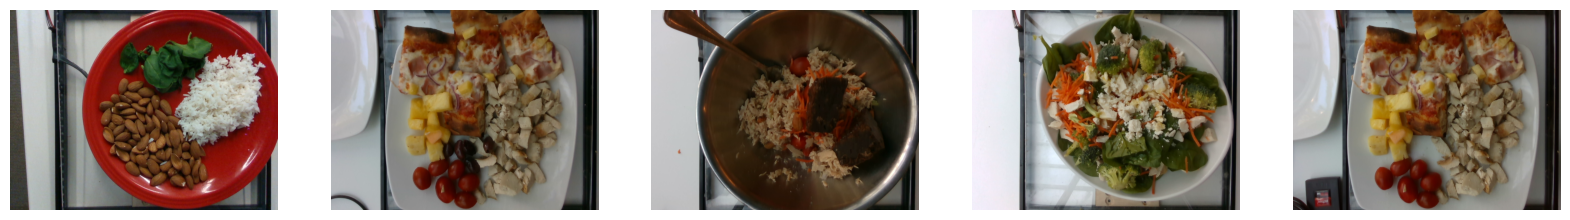

In [31]:
print('Плохо определены')
fig = plt.figure(figsize=(20, 8))
for index, id in zip(range (1, 6), list_bad):
    plt.subplot(1, 5, index)
    plt.imshow(Image.open(cfg.IMAGE_PATH + f"{id}/rgb.png").convert('RGB'))
    plt.axis('off')

Хорошо определены


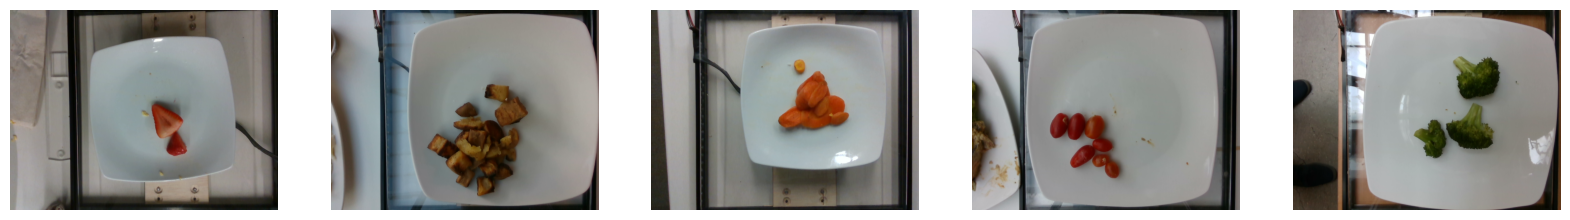

In [32]:
print('Хорошо определены')
fig = plt.figure(figsize=(20, 8))
for index, id in zip(range (1, 6), list_good):
    plt.subplot(1, 5, index)
    plt.imshow(Image.open(cfg.IMAGE_PATH + f"{id}/rgb.png").convert('RGB'))
    plt.axis('off')

Результат выполнения Этапа 4: 
- Выполнен инференс обученной на этапе 3 модели, MAE = 47.11.  
- Визуализированы топ-5 самых тяжёлых примеров для модели из test-набора, описаны возможные причины низкого качества на этих примерах, а именно: плохо были определены высококалорийные продукты, причины могут состоять в том, что модель при обучении не смогла точно определить такие продукты в смеси ингредиентов. При этом модель хорошо справляется с опредлением овощной продукции.